# Transforming Between Distance Metrics

Xuefeng Xu  
2026-02-22

Euclidean Distance, Inner Product, and Cosine Similarity are three
fundamental measures used in [nearest neighbor
search](https://en.wikipedia.org/wiki/Nearest_neighbor_search). Although
they appear different, they are deeply connected. In fact, through
simple preprocessing (normalization or dimension expansion), we can
transform one metric into another while preserving the ranking of
nearest neighbors.

## 1 Distance Metrics

Let $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$ be vectors. The three
distance metrics are defined as follows:

**Euclidean Distance (ED):**

<span id="eq-ED">$$
\|\mathbf{x} - \mathbf{y}\|=\sqrt{\sum_{i=1}^d (x_i - y_i)^2}
 \qquad(1)$$</span>

**Inner Product (IP):**

<span id="eq-IP">$$
\langle\mathbf{x}, \mathbf{y}\rangle = \sum_{i=1}^d x_i y_i
 \qquad(2)$$</span>

**Cosine Similarity (CS):**

<span id="eq-CS">$$
\cos(\mathbf{x}, \mathbf{y})=\frac{\langle\mathbf{x}, \mathbf{y}\rangle}{\|\mathbf{x}\|\|\mathbf{y}\|}
 \qquad(3)$$</span>

For Euclidean Distance, smaller values indicate more similar vectors.
For Inner Product and Cosine Similarity, larger values indicate more
similar vectors. In nearest neighbor search, given a query vector
$\mathbf{x}$, we seek the most similar vector in a database
$\{\mathbf{y}^{(i)}\}$:

<span id="eq-nns">$$
\begin{align*}
\argmin_i &\|\mathbf{x} - \mathbf{y}^{(i)}\| &\text{(ED)} \\
\argmax_i &\langle\mathbf{x}, \mathbf{y}^{(i)}\rangle &\text{(IP)} \\
\argmax_i &\cos(\mathbf{x}, \mathbf{y}^{(i)}) &\text{(CS)}
\end{align*}
 \qquad(4)$$</span>

## 2 Preprocessing

Many nearest neighbor search algorithms are optimized for specific
metrics. However, different applications may require different
similarity measures. Fortunately, these three metrics are connected
through order-preserving transformations (Bachrach et al. 2014).

By preprocessing input vectors through normalization or dimension
expansion, you can retrieve nearest neighbors for any metric by running
an algorithm compute with a different metric. This approach is
summarized in <a href="#tbl-summary" class="quarto-xref">Table 1</a> and
<a href="#fig-relation" class="quarto-xref">Figure 1</a> (see Table 2 in
Douze et al. (2025)).

| Compute | Want | Transform  |   Parameter    |
|:-------:|:----:|:----------:|:--------------:|
|   IP    |  CS  | Normalize  |      N/A       |
|   ED    |  CS  | Normalize  |      N/A       |
|   CS    |  IP  | Add 1 dim  |    $\alpha$    |
|   ED    |  IP  | Add 1 dim  |    $\alpha$    |
|   IP    |  ED  | Add 1 dim  |    $\alpha$    |
|   CS    |  ED  | Add 2 dims | $\alpha,\beta$ |

Table 1: Summary of the transformations.

<figure id="fig-relation">
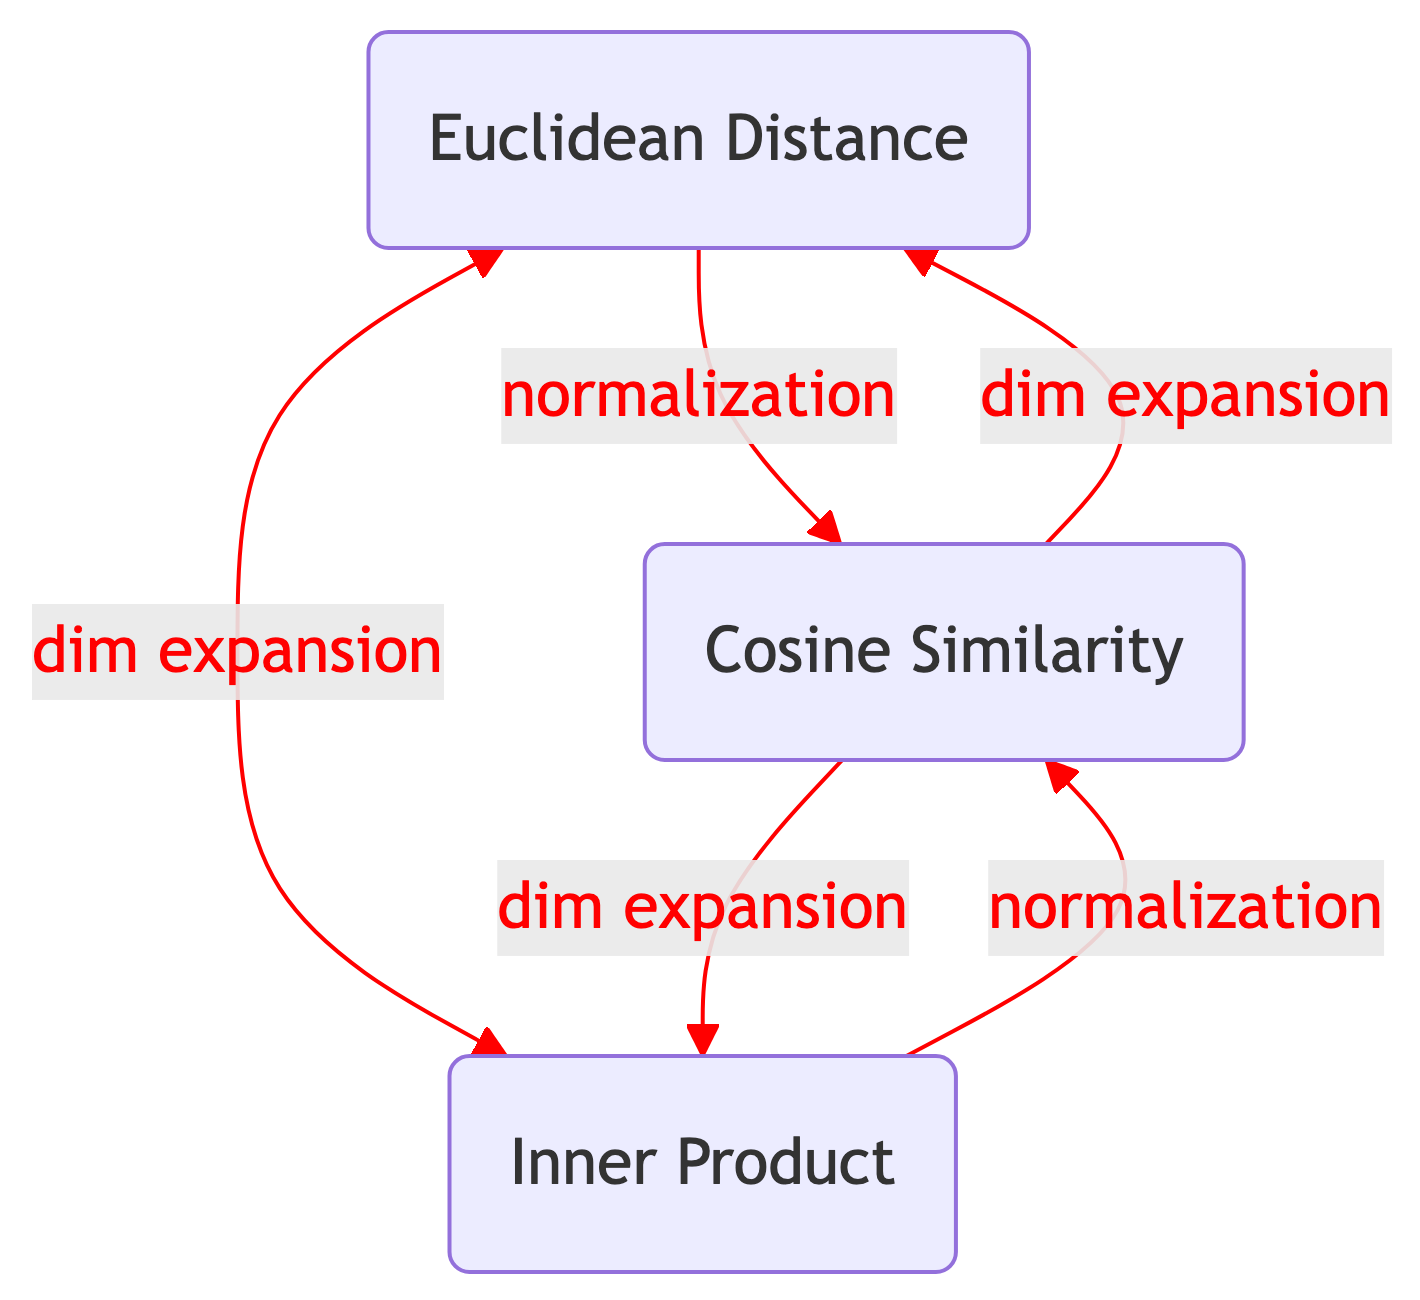
<figcaption>Figure 1: Demonstration of relationships. Arrows indicate
the transformations.</figcaption>
</figure>

## 3 Transformation

This section demonstrates how to transform between distance metrics
through order-preserving transformations. For each transformation, we
provide the mathematical formulation, a proof of correctness, and a
Python implementation to verify the results.

In [1]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

rng = np.random.default_rng(8)

d = 10
X = rng.normal(size=(1, d))
Y = rng.normal(size=(6, d))

def dist_func(X, Y, metric):
    if metric == 'ED':
        return euclidean_distances(X, Y)
    elif metric == 'IP':
        return X.dot(Y.T)
    elif metric == 'CS':
        return cosine_similarity(X, Y)
    else:
        raise ValueError(f"Unknown metric: {metric}")

### 3.1 IP –\> CS

We want the ranking results of Cosine Similarity by computing Inner
Product. Since Cosine Similarity is Inner Product on normalized vectors,
the transformation is simple normalization:

<span id="eq-ip-to-cs">$$
\begin{align*}
\text{Query: } \mathbf{x'} &= \mathbf{x}/\|\mathbf{x}\| \\
\text{Database: } \mathbf{y'} &= \mathbf{y}/\|\mathbf{y}\|
\end{align*}
 \qquad(5)$$</span>

In [2]:
def ip_to_cs(X, Y):
    Xp = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yp = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xp, Yp

<span class="proof-title">*Proof*. </span><span id="eq-proof-ip-to-cs">$$
\argmin_i \langle\mathbf{x'}, \mathbf{y'}^{(i)}\rangle = \argmin_i \cos(\mathbf{x}, \mathbf{y}^{(i)})
 \qquad(6)$$</span>

To verify the implementation, we can compare the ranking results of IP
on $\mathbf{x'}$ and $\mathbf{y'}$ with the ranking results of CS on
$\mathbf{x}$ and $\mathbf{y}$.

In [3]:
Xp, Yp = ip_to_cs(X, Y)
print("IP(X',Y'):", np.argsort(-dist_func(Xp, Yp, "IP")))
print("CS(X, Y) :", np.argsort(-dist_func(X, Y, "CS")))

IP(X',Y'): [[1 4 3 2 0 5]]
CS(X, Y) : [[1 4 3 2 0 5]]

### 3.2 ED –\> CS

We want the ranking results of Cosine Similarity by computing Euclidean
Distance. Similar to the previous case, we can also achieve this through
normalization:

<span id="eq-ed-to-cs">$$
\begin{align*}
\text{Query: } \mathbf{x'} &= \mathbf{x}/\|\mathbf{x}\| \\
\text{Database: } \mathbf{y'} &= \mathbf{y}/\|\mathbf{y}\|
\end{align*}
 \qquad(7)$$</span>

In [4]:
def ed_to_cs(X, Y):
    Xp = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yp = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xp, Yp

<span class="proof-title">*Proof*. </span><span id="eq-proof-ed-to-cs">$$
\begin{align*}
& \argmin_i \|\mathbf{x'} - \mathbf{y'}^{(i)}\| \\
=& \argmin_i 2 - 2\langle\mathbf{x'}, \mathbf{y'}^{(i)}\rangle \\
=& \argmax_i \langle\mathbf{x'}, \mathbf{y'}^{(i)}\rangle \\
=& \argmax_i \cos(\mathbf{x}, \mathbf{y}^{(i)})
\end{align*}
 \qquad(8)$$</span>

Comparing the ranking results of ED on $\mathbf{x'}$ and $\mathbf{y'}$
with the ranking results of CS on $\mathbf{x}$ and $\mathbf{y}$.

In [5]:
Xp, Yp = ed_to_cs(X, Y)
print("ED(X',Y'):", np.argsort(dist_func(Xp, Yp, "ED")))
print("CS(X, Y) :", np.argsort(-dist_func(X, Y, "CS")))

ED(X',Y'): [[1 4 3 2 0 5]]
CS(X, Y) : [[1 4 3 2 0 5]]

### 3.3 CS –\> IP

We want the ranking results of Inner Product by computing Cosine
Similarity. This can be achieved by adding one dimension to the original
vectors, where $\alpha$ is a parameter to be determined:

<span id="eq-cs-to-ip">$$
\begin{align*}
\text{Query: } \mathbf{x'} &= [\mathbf{x};0] \\
\text{Database: } \mathbf{y'} &= [\alpha\mathbf{y};\sqrt{1-\|\alpha\mathbf{y}\|^2}]
\end{align*}
 \qquad(9)$$</span>

To avoid negative values in the square root, we need to choose $\alpha$
such that:

<span id="eq-alpha-cs-to-ip">$$
\begin{gather*}
1-\|\alpha\mathbf{y}^{(i)}\|^2 \ge 0 \text{ for all } i \\
\Downarrow \\
|\alpha| \le \min_i 1/\|\mathbf{y}^{(i)}\|
\end{gather*}
 \qquad(10)$$</span>

In fact, we also need $\alpha>0$ to make sure the transformation is
order preserving (detail in the proof). So we choose $\alpha$ to be
slightly smaller than $\min_i 1/\|\mathbf{y}^{(i)}\|$.

In [6]:
def cs_to_ip(X, Y):
    Xp = np.hstack([X, np.zeros((X.shape[0], 1))])
    Y_norms = np.linalg.norm(Y, axis=1, keepdims=True)
    alpha = 1.0 / (max(Y_norms) + 1e-4)
    Yp = np.hstack([alpha * Y, np.sqrt(1 - (alpha * Y_norms)**2)])
    return Xp, Yp

<span class="proof-title">*Proof*. </span><span id="eq-proof-cs-to-ip">$$
\begin{align*}
& \argmax_i \cos(\mathbf{x'}, \mathbf{y'}^{(i)}) \\
=& \argmax_i \frac{\langle \mathbf{x'}, \mathbf{y'}^{(i)} \rangle}{\|\mathbf{x'}\|\|\mathbf{y'}^{(i)}\|} \\
=& \argmax_i \frac{\alpha\langle\mathbf{x}, \mathbf{y}^{(i)}\rangle}{\|\mathbf{x}\|} \\
=& \argmax_i \langle\mathbf{x}, \mathbf{y}^{(i)}\rangle \ (\text{require }\alpha>0) 
\end{align*}
 \qquad(11)$$</span>

Note that $\|\mathbf{x}\|$ and $\alpha$ are constants with respect to
$i$, so they don’t affect the $\argmax$ operation. We then compare the
ranking results of CS on $\mathbf{x'}$ and $\mathbf{y'}$ with the
ranking results of IP on $\mathbf{x}$ and $\mathbf{y}$.

In [7]:
Xp, Yp = cs_to_ip(X, Y)
print("CS(X',Y'):", np.argsort(-dist_func(Xp, Yp, "CS")))
print("IP(X, Y) :", np.argsort(-dist_func(X, Y, "IP")))

CS(X',Y'): [[1 4 3 2 0 5]]
IP(X, Y) : [[1 4 3 2 0 5]]

### 3.4 ED –\> IP

We want the ranking results of Inner Product by computing Euclidean
Distance. Similar to the previous case, we can also achieve this by
adding one dimension to the original vectors:

<span id="eq-ed-to-ip">$$
\begin{align*}
\text{Query: } \mathbf{x'} &= [\mathbf{x};0] \\
\text{Database: } \mathbf{y'} &= [\mathbf{y};\sqrt{\alpha^2 - \|\mathbf{y}\|^2}]
\end{align*}
 \qquad(12)$$</span>

Again, we need to choose $\alpha$ to avoid negative values in the square
root:

<span id="eq-alpha-ed-to-ip">$$
\begin{gather*}
\alpha^2 - \|\mathbf{y}^{(i)}\|^2\ge 0 \text{ for all } i\\
\Downarrow\\
|\alpha|\ge \max_i\|\mathbf{y}^{(i)}\|
\end{gather*}
 \qquad(13)$$</span>

We choose $\alpha$ to be slightly larger than
$\max_i\|\mathbf{y}^{(i)}\|$.

In [8]:
def ed_to_ip(X, Y):
    Xp = np.hstack([X, np.zeros((X.shape[0], 1))])
    Y_norms = np.linalg.norm(Y, axis=1, keepdims=True)
    alpha = max(Y_norms) + 1e-4
    Yp = np.hstack([Y, np.sqrt(alpha**2 - Y_norms**2)])
    return Xp, Yp

<span class="proof-title">*Proof*. </span><span id="eq-proof-ed-to-ip">$$
\begin{align*}
& \argmin_i \|\mathbf{x'} - \mathbf{y'}^{(i)}\| \\
=& \argmin_i \| \mathbf{x'} \|^2 + \| \mathbf{y'}^{(i)} \|^2 - 2 \langle\mathbf{x'}, \mathbf{y'}^{(i)}\rangle \\
=& \argmin_i \|\mathbf{x}\|^2 + \alpha^2 - 2\langle\mathbf{x}, \mathbf{y}^{(i)}\rangle \\
=& \argmax_i \langle\mathbf{x}, \mathbf{y}^{(i)}\rangle
\end{align*}
 \qquad(14)$$</span>

Removing $\|\mathbf{x}\|^2$ and $\alpha^2$ doesn’t affect the operation.
Again, we compare the ranking results of ED on $\mathbf{x'}$ and
$\mathbf{y'}$ with the ranking results of IP on $\mathbf{x}$ and
$\mathbf{y}$.

In [9]:
Xp, Yp = ed_to_ip(X, Y)
print("ED(X',Y'):", np.argsort(dist_func(Xp, Yp, "ED")))
print("IP(X, Y) :", np.argsort(-dist_func(X, Y, "IP")))

ED(X',Y'): [[1 4 3 2 0 5]]
IP(X, Y) : [[1 4 3 2 0 5]]

### 3.5 IP –\> ED

We want the ranking results of Euclidean Distance by computing Inner
Product. This can also be achieved by adding one dimension to the
original vectors:

<span id="eq-ip-to-ed">$$
\begin{align*}
\text{Query: } \mathbf{x'} &= [\mathbf{x};-\alpha/2] \\
\text{Database: } \mathbf{y'} &= [\mathbf{y};\|\mathbf{y}\|^2/\alpha]
\end{align*}
 \qquad(15)$$</span>

Here, $\alpha$ can be any non-zero value. For simplicity, we set
$\alpha=1$.

In [10]:
def ip_to_ed(X, Y):
    alpha = 1.0
    Xp = np.hstack([X, -alpha / 2 * np.ones((X.shape[0], 1))])
    Y_norms = np.linalg.norm(Y, axis=1, keepdims=True)
    Yp = np.hstack([Y, (Y_norms**2) / alpha])
    return Xp, Yp

<span class="proof-title">*Proof*. </span><span id="eq-proof-ip-to-ed">$$
\begin{align*}
& \argmax_i \langle\mathbf{x'}, \mathbf{y'}^{(i)}\rangle \\
=& \argmax_i \langle \mathbf{x}, \mathbf{y}^{(i)} \rangle - \|\mathbf{y}^{(i)}\|^2/2 \\
=& \argmin_i - 2\langle\mathbf{x}, \mathbf{y}^{(i)}\rangle + \|\mathbf{y}^{(i)}\|^2 + \|\mathbf{x}\|^2 \\
=& \argmin_i \|\mathbf{x} - \mathbf{y}^{(i)}\|^2
\end{align*}
 \qquad(16)$$</span>

Similarly, adding $\|\mathbf{x}\|^2$ doesn’t affect the $\argmax$
operation. We then compare the ranking results of IP on $\mathbf{x'}$
and $\mathbf{y'}$ with the ranking results of ED on $\mathbf{x}$ and
$\mathbf{y}$.

In [11]:
Xp, Yp = ip_to_ed(X, Y)
print("IP(X',Y'):", np.argsort(-dist_func(Xp, Yp, "IP")))
print("ED(X, Y) :", np.argsort(dist_func(X, Y, "ED")))

IP(X',Y'): [[1 3 0 5 4 2]]
ED(X, Y) : [[1 3 0 5 4 2]]

### 3.6 CS –\> ED

We want the ranking results of Euclidean Distance by computing Cosine
Similarity. This can be achieved by adding two dimensions, where
$\alpha$ and $\beta$ are parameters to be determined:

<span id="eq-cs-to-ed">$$
\begin{align*}
\text{Query: } \mathbf{x'} &= [\mathbf{x};-\alpha/2;0] \\
\text{Database: } \mathbf{y'} &= [\beta\mathbf{y};\beta\|\mathbf{y}\|^2/\alpha;\sqrt{1-\beta^2\|\mathbf{y}\|^2-\beta^2\|\mathbf{y}\|^4/\alpha^2}]
\end{align*}
 \qquad(17)$$</span>

To avoid negative values in the square root, we need to choose $\beta$
such that:

<span id="eq-beta-cs-to-ed">$$
\begin{gather*}
1-\beta^2\|\mathbf{y}^{(i)}\|^2-\beta^2\|\mathbf{y}^{(i)}\|^4/\alpha^2\ge 0 \text{ for all } i\\
\Downarrow\\
|\beta|\le \min_i 1/\sqrt{\|\mathbf{y}^{(i)}\|^2+\|\mathbf{y}^{(i)}\|^4/\alpha^2}
\end{gather*}
 \qquad(18)$$</span>

Here, we also need $\beta>0$ to ensure the transformation is
order-preserving (see proof). For $\alpha$, it only requires
$\alpha\neq 0$, so we simply set $\alpha=1$.

In [12]:
def cs_to_ed(X, Y):
    alpha = 1.0
    Xp = np.hstack(
        [X, -alpha / 2 * np.ones((X.shape[0], 1)), np.zeros((X.shape[0], 1))]
    )
    Y_norms = np.linalg.norm(Y, axis=1, keepdims=True)
    beta = 1.0 / max(np.sqrt(Y_norms**2 + (Y_norms**4) / alpha**2) + 1e-4)
    Yp = np.hstack(
        [
            beta * Y,
            beta * (Y_norms**2) / alpha,
            np.sqrt(1 - beta**2 * Y_norms**2 - (beta**2 * Y_norms**4) / alpha**2),
        ]
    )
    return Xp, Yp

<span class="proof-title">*Proof*. </span><span id="eq-proof-cs-to-ed">$$
\begin{align*}
& \argmax_i \cos(\mathbf{x'}, \mathbf{y'}^{(i)}) \\
=& \argmax_i \frac{\langle \mathbf{x'}, \mathbf{y'}^{(i)} \rangle}{\|\mathbf{x'}\|\|\mathbf{y'}^{(i)}\|} \\
=& \argmax_i \frac{\beta\langle \mathbf{x}, \mathbf{y}^{(i)}\rangle + \beta\|\mathbf{y}^{(i)}\|^2/2}{\sqrt{\|\mathbf{x}\|^2 + \alpha^2/4}} \\
=& \argmax_i \beta(\langle\mathbf{x}, \mathbf{y}^{(i)}\rangle - \|\mathbf{y}^{(i)}\|^2/2) \\
=& \argmax_i \langle\mathbf{x}, \mathbf{y}^{(i)}\rangle - \|\mathbf{y}^{(i)}\|^2/2 \ (\text{require }\beta>0) \\
=& \argmin_i \|\mathbf{x} - \mathbf{y}^{(i)}\|^2
\end{align*}
 \qquad(19)$$</span>

Comparing the ranking results of CS on $\mathbf{x'}$ and $\mathbf{y'}$
with the ranking results of ED on $\mathbf{x}$ and $\mathbf{y}$.

In [13]:
Xp, Yp = cs_to_ed(X, Y)
print("CS(X',Y'):", np.argsort(-dist_func(Xp, Yp, "CS")))
print("ED(X, Y) :", np.argsort(dist_func(X, Y, "ED")))

CS(X',Y'): [[1 3 0 5 4 2]]
ED(X, Y) : [[1 3 0 5 4 2]]

## 4 Side Effects

Although these transformations preserve the ranking order of nearest
neighbors, the added dimensions are not homogeneous with the original
dimensions. This can make some algorithms more difficult, especially
vector quantization methods.

In particular, Morozov and Babenko (2018) pointed out the following
issue. Suppose we want to use IP as the metric but compute with ED, so
database vectors are transformed using
<a href="#eq-ed-to-ip" class="quarto-xref">Equation 12</a>. Consider two
database vectors $\mathbf{u}$ and $\mathbf{v}$. After transformation, we
have:

<span id="eq-uv-ed-to-ip">$$
\begin{align*}
\mathbf{u'} &= [\mathbf{u};\sqrt{\alpha^2 - \|\mathbf{u}\|^2}] \\
\mathbf{v'} &= [\mathbf{v};\sqrt{\alpha^2 - \|\mathbf{v}\|^2}]
\end{align*}
 \qquad(20)$$</span>

Assume an algorithm wants to put similar vectors close to each other.
Since the algorithm is based on ED, it will try to minimize the
Euclidean distance $\|\mathbf{u'} - \mathbf{v'}\|$. In fact:

<span id="eq-ed-up-vp">$$
\begin{align*}
& \|\mathbf{u'} - \mathbf{v'}\|^2 \\
=& \|\mathbf{u'}\|^2 + \|\mathbf{v'}\|^2 - 2\langle\mathbf{u'}, \mathbf{v'}\rangle \\
=& 2\alpha^2 - 2\langle\mathbf{u}, \mathbf{v}\rangle - 2\sqrt{\alpha^2 - \|\mathbf{u}\|^2}\sqrt{\alpha^2 - \|\mathbf{v}\|^2}
\end{align*}
 \qquad(21)$$</span>

This is equivalent to maximizing the following objective:

<span id="eq-obj-up-vp">$$
\begin{align*}
& \langle\mathbf{u}, \mathbf{v}\rangle + \sqrt{\alpha^2 - \|\mathbf{u}\|^2}\sqrt{\alpha^2 - \|\mathbf{v}\|^2} \\
=& \|\mathbf{u}\|\|\mathbf{v}\|\cos(\mathbf{u}, \mathbf{v}) + \sqrt{\alpha^2 - \|\mathbf{u}\|^2}\sqrt{\alpha^2 - \|\mathbf{v}\|^2}
\end{align*}
 \qquad(22)$$</span>

However, this is not equivalent to maximizing the inner product
$\langle\mathbf{u}, \mathbf{v}\rangle$ alone, since the second term also
depends on the vector norms. Vectors with larger norms will have a
larger first term but a smaller second term. Consequently, the algorithm
will cluster vectors differently in the transformed space compared to
the original IP space, potentially leading to suboptimal results.

To illustrate this issue, we compare the ranking results of ED on
$\mathbf{u'}$ and $\mathbf{v'}$ with the ranking results of IP on
$\mathbf{u}$ and $\mathbf{v}$. The two ranking results are different.

In [14]:
_, Yp = ed_to_ip(X, Y)
Up, Vp = Yp[0].reshape(1, -1), Yp[1:]
print("ED(U',V'):", np.argsort(dist_func(Up, Vp, "ED")))

U, V = Y[0].reshape(1, -1), Y[1:]
print("IP(U, V) :", np.argsort(-dist_func(U, V, "IP")))

ED(U',V'): [[0 2 4 3 1]]
IP(U, V) : [[1 0 2 4 3]]

Douze et al. (2025) suggests several mitigation strategies, including
[random projection](https://en.wikipedia.org/wiki/Random_projection),
[Principal Component Analysis
(PCA)](https://en.wikipedia.org/wiki/Principal_component_analysis), and
other transformation techniques applied to the transformed vectors to
mitigate these side effects.

Bachrach, Yoram, Yehuda Finkelstein, Ran Gilad-Bachrach, Liran Katzir,
Noam Koenigstein, Nir Nice, and Ulrich Paquet. 2014. “Speeding up the
Xbox Recommender System Using a Euclidean Transformation for
Inner-Product Spaces.” In *Proceedings of the 8th ACM Conference on
Recommender Systems*, 257–64. RecSys ’14. New York, NY, USA: Association
for Computing Machinery. <https://doi.org/10.1145/2645710.2645741>.

Douze, Matthijs, Alexandr Guzhva, Chengqi Deng, Jeff Johnson, Gergely
Szilvasy, Pierre-Emmanuel Mazaré, Maria Lomeli, Lucas Hosseini, and
Hervé Jégou. 2025. “The Faiss Library.”
<https://arxiv.org/abs/2401.08281>.

Morozov, Stanislav, and Artem Babenko. 2018. “Non-Metric Similarity
Graphs for Maximum Inner Product Search.” In *Proceedings of the 32nd
International Conference on Neural Information Processing Systems*,
4726–35. NIPS’18. Red Hook, NY, USA: Curran Associates Inc.
<http://papers.neurips.cc/paper/7722-non-metric-similarity-graphs-for-maximum-inner-product-search>.